In [11]:
import math
import matplotlib.pyplot as plt
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import numpy as np
import pandas as pd
import statistics

normal_dist = statistics.NormalDist(0., 1.)

On considère l'EDP de pricing suivante du modèle Black-Scholes en log-espace:

$$
    \partial_t u(t, x) + \frac{\sigma^2}{2} \partial^2_{x x} u(t, x) + (r - \frac{\sigma^2}{2}) \partial_x u(t, x) - r u(t, x) = 0, \quad \forall t \in [0, T], \forall x \in \mathcal{D} \quad \mathrm{(*)}
$$
avec la condition terminale:
$$
    u(T, x) = (e^x - K)^+, \quad \forall x \in \mathcal{D}
$$

où $\mathcal{D} \subset \mathbb{R}$ est un domaine qu'on précisera par la suite. En particulier, ce sera un intervalle fermé borné, ce qui nous donne donc en particulier un problème aux limites dont les conditions aux bords seront également précisées dans ce qui suit.

## Localisation

On rappelle l'EDS de Black-Scholes en log-espace (*i.e.* $\exp(s_t)$ suivra un Black-Scholes standard):
$$
    \mathrm{d} s_t = (r - \frac{\sigma^2}{2}) \mathrm{d} t + \sigma \mathrm{d} W_t
$$

Soient $\alpha > 0$ et $t \in ]0; T]$. Notons $\bar{s}(t) := s_0 + (r - \frac{\sigma^2}{2}) t$.

On cherchera $\ell_t > 0$ tel que:
$$
    \mathbb{Q}(\bar{s}(t) - \ell_t \leq s_t \leq \bar{s}(t) + \ell_t) = 1 - \alpha \quad \mathrm{(**)}
$$

Il faut savoir retrouver que $\ell_t = \sigma \sqrt{t} F_{N(0,1)}^{-1}(1 - \frac{\alpha}{2})$, où $F_{N(0,1)}^{-1}$ est l'inverse de la fonction de répartition de la loi normale centrée réduite.

**Preuve:**

On a sous $\mathbb{Q}$ :
$$
s_t = s_0 + \Bigl(r-\frac{\sigma^2}{2}\Bigr)t + \sigma W_t,
$$
d’où
$$
s_t \sim \mathcal{N}\!\Bigl(\bar s(t),\,\sigma^2 t\Bigr),
\qquad 
\bar s(t)=s_0+\Bigl(r-\frac{\sigma^2}{2}\Bigr)t.
$$
En particulier,
$$
Z:=\frac{s_t-\bar s(t)}{\sigma\sqrt t}\sim\mathcal N(0,1).
$$
La condition
$
\mathbb{Q}\bigl(\bar s(t)-\ell_t \le s_t \le \bar s(t)+\ell_t\bigr)=1-\alpha
$
équivaut alors à
$$
\mathbb{Q}\Bigl(-\tfrac{\ell_t}{\sigma\sqrt t}\le Z\le \tfrac{\ell_t}{\sigma\sqrt t}\Bigr)=1-\alpha.
$$
En écrivant
$
\mathbb{Q}(-a\le Z\le a)=\mathbb{Q}(Z\le a)-\mathbb{Q}(Z\le -a)
$
avec
$
a=\tfrac{\ell_t}{\sigma\sqrt t},
$
et en utilisant la symétrie de la loi normale centrée,
$
\mathbb{Q}(Z\le -a)=1-\mathbb{Q}(Z\le a),
$
on obtient
$$
2\,\mathbb{Q}(Z\le a)-1=1-\alpha,
$$
et finalement
$$
\ell_t=\sigma\sqrt t\,F^{-1}_{\mathcal N(0,1)}\!\Bigl(1-\frac{\alpha}{2}\Bigr).
$$

L'équation $\mathrm{(**)}$ nous dit alors que $s_t$ sera dans l'intervalle $[\bar{s}(t) - \ell_t; \bar{s}(t) + \ell_t]$ avec une probabilité $1 - \alpha$.

1) Montrer que si on choisit $L_T = \max_{t \in [0;T]} \ell_t$ (c'est quoi?), alors on aura l'inclusion suivante:
$$
    [\bar{s}(t) - \ell_t; \bar{s}(t) + \ell_t] \subset \left[s_0 - |r - \frac{\sigma^2}{2}| T - L_T; s_0 + |r - \frac{\sigma^2}{2}| T + L_T\right]
$$

**Preuve:**

On rappelle que
$
\bar s(t)=s_0+\bigl(r-\tfrac{\sigma^2}{2}\bigr)t
$
et que
$
L_T:=\max_{t\in[0,T]}\ell_t,
$
de sorte que $\ell_t\le L_T$ pour tout $t\in[0,T]$ et $L_T = \ell_T$.

Pour tout $t\in[0,T]$, on a
$$
|\bar s(t)-s_0|
=\Bigl|r-\frac{\sigma^2}{2}\Bigr|\,t
\le \Bigl|r-\frac{\sigma^2}{2}\Bigr|\,T.
$$
Il s’ensuit que
$$
\bar s(t)-\ell_t
\ge s_0-\Bigl|r-\frac{\sigma^2}{2}\Bigr|T-L_T,
\qquad
\bar s(t)+\ell_t
\le s_0+\Bigl|r-\frac{\sigma^2}{2}\Bigr|T+L_T.
$$
D’où l’inclusion
$$
[\bar s(t)-\ell_t;\,\bar s(t)+\ell_t]
\subset
\left[
s_0-\Bigl|r-\frac{\sigma^2}{2}\Bigr|T-L_T;\;
s_0+\Bigl|r-\frac{\sigma^2}{2}\Bigr|T+L_T
\right].
$$

3) Que peut-on dire alors sur la probabilité suivante: $$\mathbb{Q}(|s_t - s_0| \leq |r - \frac{\sigma^2}{2}| T + L_T)$$

**Preuve:**

D’après l’inclusion précédente,
$$
\{\bar s(t)-\ell_t \le s_t \le \bar s(t)+\ell_t\}
\subset
\{|s_t-s_0|\le |r-\tfrac{\sigma^2}{2}|T+L_T\}.
$$
En prenant les probabilités sous $\mathbb{Q}$ et en utilisant
$
\mathbb{Q}(\bar s(t)-\ell_t \le s_t \le \bar s(t)+\ell_t)=1-\alpha,
$
on obtient
$$
\forall t\in[0,T], \quad \mathbb{Q}\bigl(|s_t-s_0|\le |r-\tfrac{\sigma^2}{2}|T+L_T\bigr)
\ge 1-\alpha.
$$

4) Conclure avec un choix raisonnable pour tronquer $\mathcal{D}$.

**Preuve:**

D’après le point précédent, pour tout $t\in[0,T]$,
$$
\mathbb{Q}\bigl(|s_t-s_0|\le |r-\tfrac{\sigma^2}{2}|T+L_T\bigr)\ge 1-\alpha.
$$
Un choix naturel pour tronquer le domaine spatial consiste donc à prendre
$$
\mathcal D=[s_{\min},s_{\max}],
\qquad
s_{\min}:=s_0-\Bigl|r-\frac{\sigma^2}{2}\Bigr|T-L_T,
\quad
s_{\max}:=s_0+\Bigl|r-\frac{\sigma^2}{2}\Bigr|T+L_T.
$$
Ce choix garantit que, à tout instant $t\in[0,T]$, la trajectoire $s_t$ appartient à $\mathcal D$ avec une probabilité au moins égale à $1-\alpha$, ce qui justifie la troncature du domaine pour l’analyse et la résolution numérique du problème.

On considère par la suite que $\mathcal{D} = [s_{\text{min}}; s_{\text{max}}]$ avec $s_{\text{min}}$ et $s_{\text{max}}$ deux bornes que vous avez déterminées ici.

Ecrire une fonction `compute_s_min` qui prend en entrée $\alpha$, $s_0$, $r$, $\sigma$, $T$ et qui retourne le $s_{\text{min}}$ choisi. Faire pareil avec `compute_s_max` pour $s_{\text{max}}$.

In [12]:
def compute_s_min(alpha, s0, r, sigma, T):
    return s0 - abs(r - 0.5 * sigma**2) * T - sigma * math.sqrt(T) * normal_dist.inv_cdf(1 - 0.5 * alpha)

def compute_s_max(alpha, s0, r, sigma, T):
    return s0 + abs(r - 0.5 * sigma**2) * T + sigma * math.sqrt(T) * normal_dist.inv_cdf(1 - 0.5 * alpha)

Vérifiez par exemple pour $s_0 = 0$, $r = 0.02$, $\sigma = 0.25$, $T = 1$ et $\alpha = 0.01$ que vous avez bien $\mathbb{Q}(s_{\text{min}} \leq s_t \leq s_{\text{max}}) \geq 1 - \alpha$ pour différents $t$.

In [13]:
def proba_test(t, s0, r, sigma, T, smin, smax):
    tmp_normal_dist = statistics.NormalDist(r - 0.5 * sigma**2, sigma * math.sqrt(t))
    return tmp_normal_dist.cdf(smax) - tmp_normal_dist.cdf(smin)

In [14]:
tmp_s_min = compute_s_min(0.01, 0., 0.02, 0.25, 1.)
tmp_s_max = compute_s_max(0.01, 0., 0.02, 0.25, 1.)
for t in (0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.):
    print(proba_test(t, 0., 0.02, 0.25, 1., tmp_s_min, tmp_s_max) > 0.99)

True
True
True
True
True
True
True
True
True
True
True


## Discrétisation

On considère deux grilles $0 =: t_0 < t_1 < \dots < t_n := T$ et $s_{\text{min}} =: s^{(0)} < s^{(1)} < \dots < s^{(m)} := s_{\text{max}}$ à pas constants respectifs $h$ et $\delta$, *i.e.*:
$$
    t_i = i h \quad\text{et}\quad s^{(j)} = s_{\text{min}} + j \delta, \quad \forall i \in \{0, \dots, n\}, \forall j \in \{0, \dots, m\}
$$

On cherche à construire une solution approchée $(u_{i,j})_{\substack{0\leq i\leq n \\ 0\leq j\leq m}}$ de la solution de l'EDP $\mathrm{(*)}$ aux points de notre grille 2D, *i.e* $u_{i,j} \approx u(t_i, s^{(j)})$.

On va faire cela via un schéma d'Euler explicite, qui s'écrit dans notre cas (il faut savoir le retrouver) pour tout $i\in\{0, \dots, n-1\}, j\in\{1, \dots, m-1\}$:
$$
    u_{i,j} = \frac{h}{2 \delta}\left(-r + (\frac{1}{\delta} + \frac{1}{2}) \sigma^2\right) u_{i+1, j-1} + \left(1 - (r + \frac{\sigma^2}{\delta^2}) h\right) u_{i+1, j} + \frac{h}{2 \delta}\left(r + (\frac{1}{\delta} - \frac{1}{2}) \sigma^2\right) u_{i+1, j+1}
$$

ou plus simplement
$$
    u_{i,j} = a u_{i+1, j-1} + b u_{i+1, j} + c u_{i+1, j+1} ,\quad \forall i\in\{0, \dots, n-1\}, \forall j\in\{1, \dots, m-1\} \quad\mathrm{(***)}
$$

où
$$
    \left\{
        \begin{aligned}
            a &= \frac{h}{2 \delta}\left(-r + (\frac{1}{\delta} + \frac{1}{2}) \sigma^2\right) \\
            b &= 1 - (r + \frac{\sigma^2}{\delta^2}) h \\
            c &= \frac{h}{2 \delta}\left(r + (\frac{1}{\delta} - \frac{1}{2}) \sigma^2\right)
        \end{aligned}
    \right.
$$

L'indice temporel $n$ correspond à la date de maturité $T$, à laquelle on connait la solution, donc on peut aussi rajouter la condition terminale sous forme discrétisée:
$$
    u_{n, j} = (e^{s^{(j)}} - K)^+, \forall j \in \{0, \dots, m\}
$$

Maintenant pour les indices $j=0$ et $j=m$ aux instants antérieurs, il nous faut des conditions aux limites.

On va considérer que pour $x$ très grand, on a $u(t,x) \approx e^x - e^{-r (T - t)} K$ (call très dans la monnaie), et que pour $x$ très petit on a $u(t,x) = 0$ (call très en dehors de la monnaie). Cela nous donne naturellement donc ces deux conditions aux bords:

$$
    \mathrm{(****)}\quad \left\{
        \begin{aligned}
            u_{i, 0} &= 0\\
            u_{i, m} &= e^{s^{(m)}} - e^{-r (T - i h)} K\\
        \end{aligned}
    \right. \quad,\forall i \in \{0, \dots, n - 1\}
$$

Si on groupe $\mathrm{(***)}$ et $\mathrm{(****)}$ ensemble, cela nous donne sous forme matricielle:
$$U^{(i)} = A U^{(i+1)} + B^{(i)}$$

où:
* $U^{(i)} := \left[u_{i,0}; u_{i,1}; \dots; u_{i, m}\right]^{\top}$;
* $A$ est la matrice $(m+1)\times(m+1)$ tridiagonale: $A = \mathrm{tridiag}(a, b, c)$;
* et $B^{(i)} := \left[\beta_0, \beta_1, \dots, \beta_m\right]^{\top}$ avec:
$$
\left\{
\begin{aligned}
\beta_0 &= -b u_{i+1, 0} - cu_{i+1, 1}\\
\beta_j &= 0 \quad,\forall j\in\{1, \dots, m-1\}\\
\beta_m &= -a u_{i+1, m-1} - b u_{i+1, m} + e^{s^{(m)}} - e^{-r (T - i h)} K
\end{aligned}
\right.
$$

1) Ecrire une fonction `explicit_matrix` qui prend en entrée $r$, $\sigma$, $h$, $\delta$, $m$ et qui retourne la matrice tridiagonale $A$ ci-dessus. Faites à la main dans un premier temps, puis réessayez en vous servant des fonctions `repeat` et `diag` de `numpy` (il faut s'intéresser en particulier au deuxième argument).

In [21]:
def explicit_matrix(r, sigma, h, delta, m):
    sigma_sq = sigma**2
    a = 0.5 * h * (-r + (0.5 + 1. / delta) * sigma_sq) / delta
    b = 1 - (r + sigma_sq / delta**2) * h
    c = 0.5 * h * (r + (-0.5 + 1. / delta) * sigma_sq) / delta
    return np.diag(np.repeat(a, m), -1) + np.diag(np.repeat(b, m + 1)) + np.diag(np.repeat(c, m), 1)

2) Ecrire une fonction `boundary_cond_vector` qui prend en entrée $i$, $r$, $\sigma$, $h$, $\delta$, $T$, $s_{max}$, $K$ ainsi que $U^{(i+1)}$ (qu'on appelera `u_next` dans cette fonction) et qui retourne le vecteur $B^{(i)}$ ci-dessus.

In [16]:
def boundary_cond_vector(i, r, sigma, h, delta, T, s_max, K, u_next):
    sigma_sq = sigma**2
    a = 0.5 * h * (-r + (0.5 + 1. / delta) * sigma_sq) / delta
    b = 1 - (r + sigma_sq / delta**2) * h
    c = 0.5 * h * (r + (-0.5 + 1. / delta) * sigma_sq) / delta
    res = np.zeros_like(u_next)
    res[0] = -b * u_next[0] - c * u_next[1]
    res[-1] = -a * u_next[-2] - b * u_next[-1] + math.exp(s_max) - math.exp(-r * (T - i * h)) * K
    return res

3) Combinez vos deux fonctions pour faire un solveur qui itère sur les pas de temps $i$, en commençant avec $i = n$, jusqu'à arriver à calculer $U^{(0)}$. Votre solveur sera appelable via une fonction `explicit_scheme_price` qui prend en entrée $r$, $\sigma$, $T$, $K$, $s_0$, $\alpha$, $m$, $n$ ainsi qu'un argument booléen `midpoint` et qui donne en sortie le prix approché en $(t_0, s_0)$ si `midpoint == True` et qui retourne le vecteur $U^{(0)}$ ainsi que la grille $\{s^{(i)}\}_{0 \leq i \leq m}$ sinon. Vous aurez besoin entre autres de la fonction `linspace` de `numpy`.

In [46]:
def explicit_scheme_price(r, sigma, T, K, s0, alpha, m, n, midpoint):
    s_min = compute_s_min(alpha, s0, r, sigma, T)
    s_max = compute_s_max(alpha, s0, r, sigma, T)
    delta = (s_max - s_min) / (m - 1)
    h = T / (n - 1)
    K = 1.
    A = explicit_matrix(r, sigma, h, delta, m - 1)
    s_grid = np.linspace(s_min, s_max, num=m)
    u = np.maximum(np.exp(s_grid) - K, 0.)
    for i in range(n - 1):
        b = boundary_cond_vector(n - 2 - i, r, sigma, h, delta, T, s_max, K, u)
        u = A@u + b
    if midpoint:
        return float(u[m // 2])
    else:
        return u, s_grid

4) Ecrivez une fonction `closed_formula_price` qui prend en entrée $r$, $\sigma$, $T$, $K$, $s_0$ et qui implémente la formule fermée de Black-Scholes pour le prix du call européen vanille considéré. On rappelle que ce prix s'écrit $$S_0\cdot F_{N(0,1)}(d_1) - K \cdot e^{-rT} \cdot F_{N(0,1)}(d_2)$$

où $S_0 = \exp(s_0)$ et

$$d_1 = \frac{\ln\left(\frac{S_0}{K}\right) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}$$
$$d_2 = d_1 - \sigma\sqrt{T}$$

Comparez ce que vous obtenez avec cette formule fermée et ce que donne le schéma d'Euler explicite avec ce que vous avez implémenté dans la question 3. Utilisez comme paramètres $\alpha = 0.001$, $s_0 = 0$, $r = 0.02$, $\sigma = 0.25$, $T = 1$, $K = 1$, $m = 513$ et $n = 5891$. Vous verrez plus bas d'où vient le nombre magique 5891.

In [18]:
def closed_formula_price(r, sigma, T, K, s0):
    sigma_sqrtT = sigma * math.sqrt(T)
    d1 = (s0 - math.log(K) + (r + 0.5 * sigma**2) * T) / sigma_sqrtT
    d2 = d1 - sigma_sqrtT
    return math.exp(s0) * normal_dist.cdf(d1) - K * math.exp(-r * T) * normal_dist.cdf(d2)

In [40]:
closed_formula_price(0.02, 0.25, 1., 1., 0.)

0.10870558490557586

In [41]:
explicit_scheme_price(0.02, 0.25, 1., 1., 0., 0.001, 513, 5891, True)

0.10869433538644069

Les deux prix sont super proches, donc on est contents.

5) Tracez un graphe du prix à la date $0$ en fonction de $s$ en utilisant ce que vous obtenez avec `explicit_scheme_price` en utilisant les mêmes paramètres qu'avant mais en donnant `False` pour l'argument booléen.

In [47]:
prices, s_grid = explicit_scheme_price(0.02, 0.25, 1., 1., 0., 0.001, 513, 5891, False)

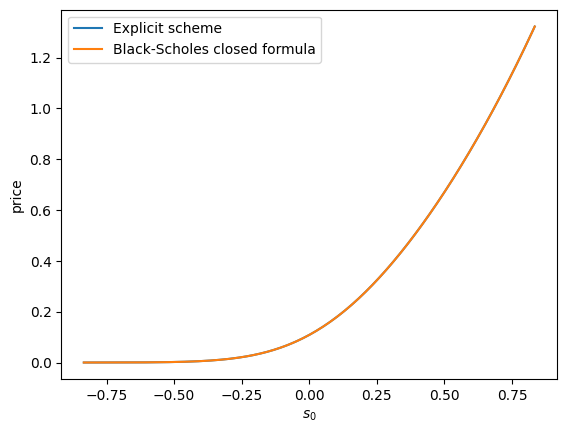

In [48]:
plt.plot(s_grid, prices, label='Explicit scheme')
plt.plot(s_grid, [closed_formula_price(0.02, 0.25, 1., 1., s0) for s0 in s_grid], label='Black-Scholes closed formula')
plt.xlabel('$s_0$')
plt.ylabel('price')
plt.legend();

L'abscisse est en log-espace, donc ce ne sont pas vraiment des niveaux du sous-jacent, mais les logs de ceux-ci. On va changer d'échelle en appliquant une `exp` sur les abscisses pour avoir nos graphes en fonction du niveau du sous-jacent:

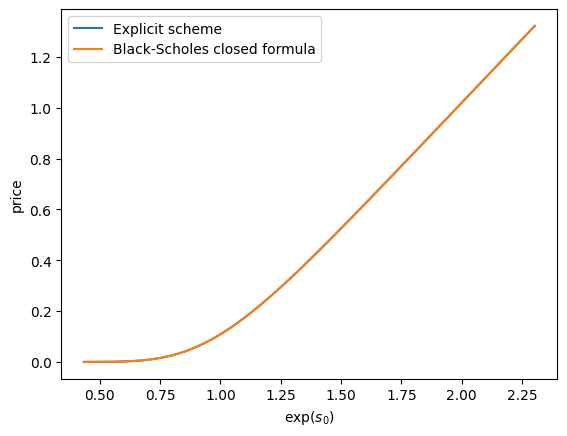

In [49]:
exp_s_grid = np.exp(s_grid)
plt.plot(exp_s_grid, prices, label='Explicit scheme')
plt.plot(exp_s_grid, [closed_formula_price(0.02, 0.25, 1., 1., s0) for s0 in s_grid], label='Black-Scholes closed formula')
plt.xlabel(r'$\exp(s_0)$')
plt.ylabel('price')
plt.legend();

## Stabilité du schéma numérique

En utilisant les mêmes paramètres que la question 4 de la section précédente, définissez une fonction `compute_err` qui pour un couple `mn` (ie un tuple de taille 2 où le premier élément joue le rôle de `m` et le second celui de `n`) calcule l'écart en valeur absolue entre le prix par formule fermée (considéré comme notre référence) et le prix approché correspondant obtenu par le schéma explicite.

Calculez ensuite cette erreur pour toutes les valeurs possibles de $m$ et $n$ dans l'ensemble $\left\{2^4, 2^5, 2^6, 2^7, 2^8, 2^9, 2^{10}, 2^{11}\right\}$.

**Petit conseil**: comme ce sera long à faire en séquentiel, il vaut mieux paralléliser ce calcul exhaustif. Pensez à utiliser `Pool` du module `multiprocessing` (voir l'introduction dans https://docs.python.org/3/library/multiprocessing.html) et utilisez comme nombre de processus un nombre autour du nombre de coeurs que vous avez sur votre PC. Si `multiprocessing` ne marche pas sur votre installation, une alternative est `concurrent.futures`, voir: https://docs.python.org/3/library/concurrent.futures.html (dans ce cas en particulier vous allez devoir utiliser un `ProcessPoolExecutor`).

En général, si vous avez une fonction `f` qui à une entrée `x` associe `f(x)`, et que vous voulez évaluer `f` en chaque point d'une collection `L` de façon parallèle, vous pouvez le faire avec l'une des deux méthodes suivantes:
* avec `multiprocessing` (`from multiprocessing import Pool`):
```
L = ... # une liste d'inputs sur lesquels on souhaite paralléliser f

def f(x):
    # fait quelque chose et retourne un resultat

with Pool(8) as p: # 8 est à remplacer par le nombre de coeurs que vous avez, ou moins si vous voulez paralléliser encore moins
    resultats = p.map(f, L)

# maintenant pour tout i, resultats[i] va être égal à f(L[i]), et tous ces résultats auront été calculés en parallèle
```
* avec `concurrent.futures` (`from concurrent.futures import ProcessPoolExecutor`):
```
L = ... # une liste d'inputs sur lesquels on souhaite paralléliser f

def f(x):
    # fait quelque chose et retourne un resultat

with ProcessPoolExecutor(max_workers=8) as executor: # 8 est à remplacer par le nombre de coeurs que vous avez, ou moins si vous voulez paralléliser encore moins
    resultats = list(executor.map(f, L))
```

Si aucune des deux ne marche (très dépendant de l'OS...), essayez de mettre le bloc `with` au sein d'un `if __name__ == '__main__'`comme suit:
```
if __name__ == '__main__':
    with Pool(8) as p:
        resultats = p.map(f, L)
```

Pensez à représenter le résultat obtenu sous forme d'une matrice d'erreurs $8 \times 8$ dans une jolie `DataFrame` avec comme index et colonnes les puissances de 2 ci-dessus.

In [50]:
# Solution avec multiprocessing

r = 0.02
sigma = 0.25
T = 1.
K = 1.
s0 = 0.
alpha = 0.001

candidates = [2**i for i in range(4, 12)]
ref_price = closed_formula_price(0.02, 0.25, 1., 1., 0.)

def compute_err(mn):
    m, n = mn
    return abs(explicit_scheme_price(0.02, 0.25, 1., 1., 0., 0.001, m, n, True) - ref_price)

with Pool(8) as p:
    candidate_pairs = [(m, n) for m in candidates for n in candidates]
    errors = p.map(compute_err, candidate_pairs)

Process SpawnPoolWorker-1:
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py", line 389, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'compute_err' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>
Process SpawnPoolWorker-2:
Traceba

KeyboardInterrupt: 

In [51]:
# Solution avec concurrent.futures

r = 0.02
sigma = 0.25
T = 1.
K = 1.
s0 = 0.
alpha = 0.001

candidates = [2**i for i in range(4, 12)]
ref_price = closed_formula_price(0.02, 0.25, 1., 1., 0.)

def compute_err(mn):
    m, n = mn
    return abs(explicit_scheme_price(0.02, 0.25, 1., 1., 0., 0.001, m, n, True) - ref_price)

with ProcessPoolExecutor(max_workers=8) as executor:
    candidate_pairs = [(m, n) for m in candidates for n in candidates]
    errors = list(executor.map(compute_err, candidate_pairs))

Process SpawnProcess-41:
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/concurrent/futures/process.py", line 252, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'compute_err' on <module '__main__' (<class '_frozen

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

Les warnings relatives à des overflows/NaNs sont normales, comme on va le voir la résolution est très instable numériquement pour certains choix de $m$ et $n$...

In [21]:
errors_df = pd.DataFrame(
    index=candidates,
    columns=candidates,
    data=np.array(errors).reshape(8, 8)
)

errors_df

,16,32,64,128,256,512,1024,2048
16,3.657892e-02,3.615219e-02,3.594992e-02,3.585138e-02,3.580275e-02,0.035779,3.576654e-02,0.035761
32,6.376277e-01,1.685247e-02,1.664250e-02,1.654016e-02,1.648962e-02,0.016465,1.645200e-02,0.016446
64,1.178830e+11,1.053934e+16,1.281255e+11,7.997028e-03,7.946345e-03,0.007921,7.908610e-03,0.007902
128,2.256115e+20,4.067269e+36,4.697473e+58,2.236165e+79,1.524881e+61,0.003900,3.887064e-03,0.003881
256,1.707435e+29,3.272221e+55,2.479954e+98,1.260817e+164,1.499577e+253,NaN,2.479556e+267,0.001930
512,1.018020e+38,1.068805e+74,3.647049e+136,1.979827e+242,NaN,NaN,NaN,NaN
1024,5.666771e+46,2.745613e+92,2.203578e+174,NaN,NaN,NaN,NaN,NaN
2048,3.085396e+55,6.574248e+110,1.045961e+212,NaN,NaN,NaN,NaN,NaN


Pour chacun des $m$ jusqu'à $256$, relevez le plus petit $n$ à partir duquel vous observez que l'erreur commence à avoir le même ordre de grandeur que celle pour $n=2048$. Comparez à $n_{\text{CFL}}$ où:
$$n_{\text{CFL}} = \lfloor\frac{T}{h_{\text{CFL}}}\rfloor + 1$$

et
$$h_{\text{CFL}} = \left(\frac{\delta}{\sigma}\right)^2$$

Conclusion?

In [16]:
def n_cfl(alpha, s0, r, sigma, T, m):
    s_min = compute_s_min(alpha, s0, r, sigma, T)
    s_max = compute_s_max(alpha, s0, r, sigma, T)
    h_cfl = ((s_max - s_min) / (sigma * (m - 1)))**2
    return math.floor(T / h_cfl) + 1

In [17]:
n_cfl_df = pd.DataFrame(
    {
        'n_cfl': 
        {
            m: n_cfl(alpha, s0, r, sigma, T, m)
            for m in candidates
        }
    }
)

n_cfl_df

,n_cfl
16,6
32,22
64,90
128,363
256,1462
512,5868
1024,23516
2048,94156


In [18]:
errors_df.join(n_cfl_df)

,16,32,64,128,256,512,1024,2048,n_cfl
16,3.657892e-02,3.615219e-02,3.594992e-02,3.585138e-02,3.580275e-02,0.035779,3.576654e-02,0.035761,6
32,6.376277e-01,1.685247e-02,1.664250e-02,1.654016e-02,1.648962e-02,0.016465,1.645200e-02,0.016446,22
64,1.178830e+11,1.053934e+16,1.281255e+11,7.997028e-03,7.946345e-03,0.007921,7.908610e-03,0.007902,90
128,2.256115e+20,4.067269e+36,4.697473e+58,2.236165e+79,1.524881e+61,0.003900,3.887064e-03,0.003881,363
256,1.707435e+29,3.272221e+55,2.479954e+98,1.260817e+164,1.499577e+253,NaN,2.479556e+267,0.001930,1462
512,1.018020e+38,1.068805e+74,3.647049e+136,1.979827e+242,NaN,NaN,NaN,NaN,5868
1024,5.666771e+46,2.745613e+92,2.203578e+174,NaN,NaN,NaN,NaN,NaN,23516
2048,3.085396e+55,6.574248e+110,1.045961e+212,NaN,NaN,NaN,NaN,NaN,94156


(voir le cours)

Donc oui le schéma explicite est très facile à implémenter (c'est pourquoi nous avons commencé avec), mais niveau stabilité ce n'est pas terrible et on est obligé de choisir un nombre de pas de temps trop élevé (donc résolution super lente puisque ça se traduira par un grand nombre d'itérations dans notre solveur) pour espérer approcher la solution exacte. Par exemple, si on divise le pas en espace par 2, on sera obligé à peu près de diviser le pas en temps par 4 pour rester dans le régime de validité de la condition de CFL...

Ces problèmes de stabilité motiveront l'introduction du schéma implicite et du schéma de Crank-Nicholson plus tard.

## (avancé) Faire un petit peu plus vite

La multiplication matrice-vecteur `A @ x` dans `explicit_scheme_price` est de complexité $\Theta(n^2)$. Cependant, la matrice `A` étant tridiagonale, une routine de multiplication matricielle générique telle que celle de `numpy` ferait énormément de multiplications inutiles par $0$.

Nous pouvons normalement faire mieux en l'implémentant nous-mêmes sous la forme d'une boucle (complexité linéaire $\Theta(n)$, pourquoi?). Hélas sur Python, un langage interprété, une boucle est en général lente car on fait appel à l'interpréteur à chaque itération, tandis que les routines vectorielles de `numpy` passent par l'interpréteur une seule fois lors de l'appel et c'est ensuite un code précompilé qui se charge du reste.

Heureusement avec des packages comme `numba`, on peut compiler certaines portions de code Python via une compilation *juste-à-temps* (JIT pour *just-in-time* en anglais). Voir https://numba.pydata.org/.

In [19]:
import numba as nb

@nb.jit(nopython=True, inline='always', error_model='numpy')
def tridiag_mult(a, b, c, x):
    out = np.empty_like(x)
    size = out.size
    x_0 = x[0]
    x_1 = x[1]
    out[0] = b * x_0 + c * x_1
    for i in range(1, size - 1):
        x_2 = x[i + 1]
        out[i] = a * x_0 + b * x_1 + c * x_2
        x_0 = x_1
        x_1 = x_2
    out[size - 1] = a * x_0 + b * x_1
    return out

On réécrit donc notre fonction `explicit_scheme_price` et on appelle cette nouvelle variante `fast_explicit_scheme_price`:

In [20]:
def fast_explicit_scheme_price(r, sigma, T, K, s0, alpha, m, n, midpoint):
    s_min = compute_s_min(alpha, s0, r, sigma, T)
    s_max = compute_s_max(alpha, s0, r, sigma, T)
    delta = (s_max - s_min) / (m - 1)
    h = 1. / (n - 1)
    K = 1.
    sigma_sq = sigma**2
    a = 0.5 * h * (-r + (0.5 + 1. / delta) * sigma_sq) / delta
    b = 1 - (r + sigma_sq / delta**2) * h
    c = 0.5 * h * (r + (-0.5 + 1. / delta) * sigma_sq) / delta
    s_grid = np.linspace(s_min, s_max, num=m)
    u = np.maximum(np.exp(s_grid) - K, 0.)
    for i in range(n - 1):
        boundary_vec = boundary_cond_vector(i, r, sigma, h, delta, T, s_max, K, u)
        u = tridiag_mult(a, b, c, u)
        u += boundary_vec
    if midpoint:
        return float(u[m // 2])
    else:
        return u, s_grid

In [21]:
%%timeit
explicit_scheme_price(r, sigma, T, K, s0, alpha, 513, n_cfl(alpha, s0, r, sigma, T, 513), True)

478 ms ± 93.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [22]:
%%timeit
fast_explicit_scheme_price(r, sigma, T, K, s0, alpha, 513, n_cfl(alpha, s0, r, sigma, T, 513), True)

42.6 ms ± 4.59 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


On peut faire une variante de `tridiag_mult` où on écrase le vecteur `x` au lieu d'allouer un nouveau vecteur à chaque fois, devrait être encore plus rapide...

In [29]:
@nb.jit(nopython=True, inline='always', error_model='numpy')
def tridiag_mult_inplace(a, b, c, x):
    size = x.size
    x_0 = x[0]
    x_1 = x[1]
    x[0] = b * x_0 + c * x_1
    for i in range(1, size - 1):
        x_2 = x[i + 1]
        x[i] = a * x_0 + b * x_1 + c * x_2
        x_0 = x_1
        x_1 = x_2
    x[size - 1] = a * x_0 + b * x_1

Comme on s'attend à ce que ce soit plus rapide, on utilisera bien évidemment le préfixe `faster` cette fois-ci... Et d'ailleurs, on en profitera pour mettre la boucle principale dans une fonction à part pour qu'on puisse la JITter elle-aussi. On va également simplifier `boundary_cond_vector` en settant directement nous-même la première et dernière coordonnées, relatives aux conditions aux bords, car l'addition est superflue.

In [30]:
@nb.jit(nopython=True, inline='always', error_model='numpy')
def explicit_scheme_mainloop(n, r, s_max, K, T, h, a, b, c, u):
    for i in range(n - 1):
        # on fait notre multiplication optimisée par la matrice A de façon in-place
        tridiag_mult_inplace(a, b, c, u)
        # c'est super simple pour les conditions aux bords finalement...
        u[0] = 0.
        u[-1] = math.exp(s_max) - math.exp(-r * (T - i * h)) * K
        # c'est fini pour cette itération...
    # pas besoin de retourner quoi que ce soit car on travaille sur u directement

def faster_explicit_scheme_price(r, sigma, T, K, s0, alpha, m, n, midpoint):
    s_min = compute_s_min(alpha, s0, r, sigma, T)
    s_max = compute_s_max(alpha, s0, r, sigma, T)
    delta = (s_max - s_min) / (m - 1)
    h = 1. / (n - 1)
    K = 1.
    sigma_sq = sigma**2
    a = 0.5 * h * (-r + (0.5 + 1. / delta) * sigma_sq) / delta
    b = 1 - (r + sigma_sq / delta**2) * h
    c = 0.5 * h * (r + (-0.5 + 1. / delta) * sigma_sq) / delta
    s_grid = np.linspace(s_min, s_max, num=m)
    u = np.maximum(np.exp(s_grid) - K, 0.)
    explicit_scheme_mainloop(n, r, s_max, K, T, h, a, b, c, u)
    if midpoint:
        return float(u[m // 2])
    else:
        return u, s_grid

In [31]:
%%timeit
faster_explicit_scheme_price(r, sigma, T, K, s0, alpha, 513, n_cfl(alpha, s0, r, sigma, T, 513), True)

2.33 ms ± 102 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
